In [1]:
import torch
import re
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [2]:
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

mps


In [21]:
stories=[]
with open('TinyStories-train.txt','r') as f:
    story=''
    count=0
    for line in f:
        story += line
        if line.rstrip() == '<|endoftext|>':
            stories.append(story)
            story=''
            count+=1
            if count == 50000:
                break
len(stories)

50000

In [22]:
vocab = set(['<|startoftext|>'])
word_level_stories = []
for text in stories:
    pattern = r"<\|.*?\|>|\n|[a-zA-Z]+|[.,!?\"']"
    tokens = re.findall(pattern, text)
    vocab.update(tokens)
    word_level_stories.append(tokens)
vocab = list(sorted(vocab))
vocab_size_p=len(vocab)
start = next(i for i, word in enumerate(vocab) if word == '<|startoftext|>')
end = next(i for i, word in enumerate(vocab) if word == '<|endoftext|>')
vocab_size_p,start,end,len(word_level_stories)

(16490, 7, 6, 50000)

2 1110 218


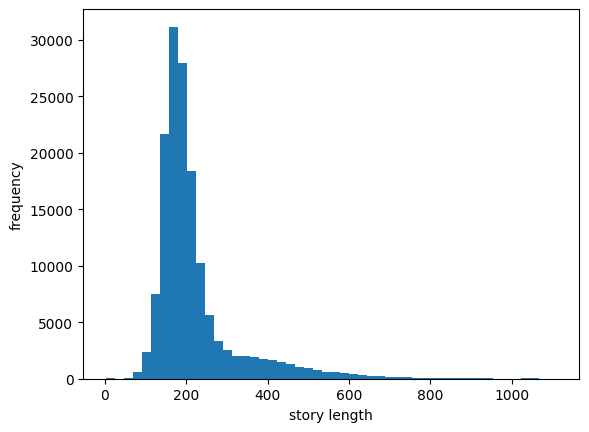

In [304]:
lengths = [len(story) for story in word_level_stories]
print(min(lengths), max(lengths), sum(lengths)//len(lengths))

plt.hist(lengths, bins=50)
plt.xlabel('story length')
plt.ylabel('frequency')
plt.show()

In [305]:
word_to_i = { word:i for i,word in enumerate(vocab)}
i_to_word = { i:word for i,word in enumerate(vocab)}

In [306]:
context_len = 256

def build_dataset(stories):
    xs, ys = [], []
    for words in stories:
        context = [start] + [word_to_i[word] for word in words[:-1]]
        out = [word_to_i[word] for word in words[:-1]] + [end]
        
        # truncate
        context = context[:context_len]
        out = out[:context_len]
        
        # pad
        context += [-1] * (context_len - len(context))
        out += [-1] * (context_len - len(out))
        
        xs.append(torch.tensor(context).to(device))
        ys.append(torch.tensor(out).to(device))
    
    return torch.stack(xs).to(device), torch.stack(ys).to(device)

import random
random.seed(42)
random.shuffle(word_level_stories)
n1 = int(0.8*len(word_level_stories))
n2 = int(0.9*len(word_level_stories))

Xtr,  Ytr  = build_dataset(word_level_stories[:n1])     # 80%
Xdev, Ydev = build_dataset(word_level_stories[n1:n2])   # 10%
Xte,  Yte  = build_dataset(word_level_stories[n2:])     # 10%

Xtr.shape,Ytr.shape, Xdev.shape,Ydev.shape, Xte.shape,Yte.shape

(torch.Size([120000, 256]),
 torch.Size([120000, 256]),
 torch.Size([15000, 256]),
 torch.Size([15000, 256]),
 torch.Size([15000, 256]),
 torch.Size([15000, 256]))

In [6]:
n_embed = 32
n_hidd = 256
batch_size = 32
context_len = 256

In [132]:
g = torch.Generator().manual_seed(2147483647)
#embedding
C = torch.randn((vocab_size,n_embed),generator=g).to(device)
#attention
Wa = torch.randn((context_len,context_len),generator=g).to(device)*0.1
#first layer
W1 = torch.randn((context_len,n_hidd),generator=g).to(device)*0.1
b1 = torch.randn((n_hidd),generator=g).to(device)*0.1
#second layer
W2 = torch.randn((n_hidd,n_hidd),generator=g).to(device)*0.1
b2 = torch.randn((n_hidd),generator=g).to(device)*0.1
#logits layer
W3 = torch.randn((n_hidd,vocab_size),generator=g).to(device)*0.1
b3 = torch.randn((vocab_size),generator=g).to(device) * 0
parameters = [C, Wa, W1, b1, W2, b2, W3, b3]
for p in parameters:
    p.requires_grad = True

In [152]:
for i in range(1):
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    xi = Xtr[idx].to(device)  # (32, context_len)
    yi = Ytr[idx].to(device)  # (32, context_len)
    
    mask = (xi == -1).to(device)
    E = C[xi.clamp(min=0)]
    E = E.masked_fill(mask.unsqueeze(-1),0.0)
    
    seq_len = xi.shape[1]
    causal_mask = torch.ones(seq_len, seq_len).tril(diagonal=0)  # lower triangle, diagonal excluded
    causal_mask = (causal_mask == 0).to(device)  # positions to mask out (upper tri + diagonal)
    
    apre = E @ E.transpose(-1, -2)
    apre_soft = Wa @ apre
    apre_soft = apre_soft.masked_fill(causal_mask, float('-inf'))
    
    #attention
    a = F.softmax(apre_soft, dim=1)
    print(a.shape)
    #first layer
    x1 = torch.relu((a @ W1) + b1)
    
    #second layer
    x2 = torch.relu((x1 @ W2) + b2)
    
    #logits layer
    logits = ((x2 @ W3) + b3).to(device)
    
    loss = F.cross_entropy(
        logits.view(-1, vocab_size),  # (batch*context_len, vocab_size)
        yi.view(-1),                   # (batch*context_len,)
        ignore_index=-1,
        reduction='mean'
    )
    
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += (-0.5) * p.grad
    print('loss: ',loss.item())

torch.Size([32, 256, 256])
loss:  8.637447357177734


In [139]:
#------------------------------------- USING nn MODULE ------------------------------------------------#

In [7]:
class AttentionModel(nn.Module):
    def __init__(self, n_embed, n_hidd, context_len, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size,n_embed,-1)
        self.position = nn.Embedding(context_len, n_embed)
        self.Wa = nn.Parameter(torch.randn((n_embed,context_len)) * 0.01)
        self.Wb = nn.Parameter(torch.randn((n_embed,context_len)) * 0.01)
        self.Wc = nn.Parameter(torch.randn((n_embed,context_len)) * 0.01)
        self.layer_norm = nn.LayerNorm(context_len)
        self.first_linear = nn.Linear(context_len,n_hidd)
        self.le_relu1 = nn.LeakyReLU(0.01)
        self.second_linear = nn.Linear(n_hidd,n_hidd)
        self.le_relu2 = nn.LeakyReLU(0.01)
        self.third_linear = nn.Linear(n_hidd,n_hidd)
        self.le_relu3 = nn.LeakyReLU(0.01)
        self.logits_linear = nn.Linear(n_hidd,vocab_size)
        
    def forward(self, x):
        pad_mask = (x == -1)
        x = self.embedding(x)  # (batch, context_len, n_embed)
        
        # causal mask
        seq_len = x.shape[1]
        causal_mask = torch.ones(seq_len, seq_len).tril(diagonal=0)
        causal_mask = (causal_mask == 0).to(x.device)

        positional_vectors = self.position(torch.arange(seq_len).to(x.device))
        x = x + positional_vectors
        
        attn = ((x @ self.Wa) @ (x @ self.Wb).transpose(-1, -2)) * (x.shape[1] ** -0.5)  # (batch, context_len, context_len)
        # attn = attn @ self.Wa
        
        attn = attn.masked_fill(causal_mask, float('-inf'))
        
        # pad mask
        pad_mask = pad_mask.unsqueeze(1).expand(-1, seq_len, seq_len).to(x.device)
        attn = attn.masked_fill(pad_mask, float('-inf'))
        
        attn = F.softmax(attn, dim=-1)
        x = attn @ (x @ self.Wc)
        x = self.layer_norm(x)
        x = self.first_linear(x)
        x = self.le_relu1(x)
        x = self.second_linear(x)
        x = self.le_relu2(x)
        x = self.t_linear(x)
        x = self.le_relu2(x)
        x = self.logits_linear(x)
        return x

In [8]:
model = AttentionModel(n_embed,n_hidd,context_len,vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=-1,reduction='mean')

NameError: name 'vocab_size' is not defined

In [267]:
for param_group in optimizer.param_groups:
        param_group['lr'] = 1e-3

step 0 loss: 3.8875
step 100 loss: 3.8404
step 200 loss: 3.8645
step 300 loss: 3.9089
step 400 loss: 3.9937
step 500 loss: 3.9812
step 600 loss: 3.8177
step 700 loss: 3.8513
step 800 loss: 3.7236
step 900 loss: 3.7671
step 1000 loss: 3.6927
step 1100 loss: 3.8898
step 1200 loss: 3.8184
step 1300 loss: 3.6635
step 1400 loss: 3.8697
step 1500 loss: 3.7306
step 1600 loss: 3.9184
step 1700 loss: 3.7051
step 1800 loss: 3.7571
step 1900 loss: 3.4821
step 2000 loss: 3.8025
step 2100 loss: 3.6763
step 2200 loss: 3.6650
step 2300 loss: 3.7436
step 2400 loss: 3.7062
step 2500 loss: 3.6472
step 2600 loss: 3.6756
step 2700 loss: 3.6864
step 2800 loss: 3.6108
step 2900 loss: 3.6525


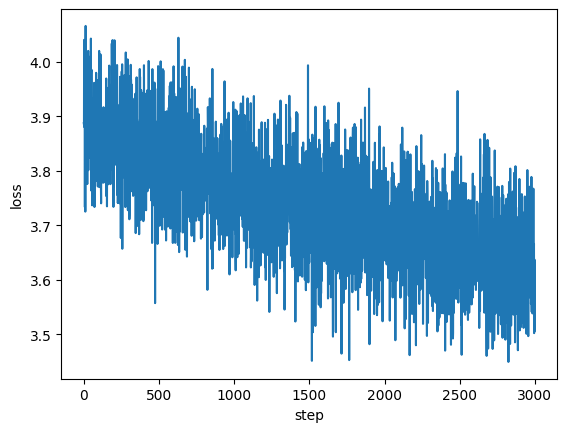

In [299]:
# learning about correct learning rate
losses = []
for i in range(3000):
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    xi = Xtr[idx].to(device)
    yi = Ytr[idx].to(device)
    logits = model(xi)
    optimizer.zero_grad()
    loss = criterion(logits.view(-1, vocab_size), yi.view(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if i % 100 == 0:
        print(f"step {i} loss: {loss.item():.4f}")

plt.plot(losses)
plt.xlabel('step')
plt.ylabel('loss')
plt.show()

In [300]:
model.eval()
with torch.no_grad():
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    xi = Xtr[idx].to(device)
    yi = Ytr[idx].to(device)
    logits = model(xi)
    dev_loss = criterion(logits.view(-1, vocab_size), yi.view(-1))
    print(f"train loss: {dev_loss.item():.4f}")
model.eval()
with torch.no_grad():
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    xi = Xtr[idx].to(device)
    yi = Ytr[idx].to(device)
    logits = model(xi)
    dev_loss = criterion(logits.view(-1, vocab_size), yi.view(-1))
    print(f"dev loss: {dev_loss.item():.4f}")
model.train()

train loss: 3.5532
dev loss: 3.6218


AttentionModel(
  (embedding): Embedding(16490, 32, padding_idx=16489)
  (position): Embedding(256, 32)
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (first_linear): Linear(in_features=256, out_features=256, bias=True)
  (le_relu1): LeakyReLU(negative_slope=0.01)
  (second_linear): Linear(in_features=256, out_features=256, bias=True)
  (le_relu2): LeakyReLU(negative_slope=0.01)
  (logits_linear): Linear(in_features=256, out_features=16490, bias=True)
)

In [147]:
for i in range(10):
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    xi = Xtr[idx].to(device)  # (32, context_len)
    yi = Ytr[idx].to(device)  # (32, context_len)

    logits = model(xi)

    optimizer.zero_grad()
    loss = criterion(
        logits.view(-1, vocab_size),  # (batch*context_len, vocab_size)
        yi.view(-1)
    )
    loss.backward()
    optimizer.step()
    print("loss: ", loss.item())

loss:  9.709768295288086
loss:  9.707533836364746
loss:  9.704302787780762
loss:  9.701401710510254
loss:  9.703556060791016
loss:  9.700332641601562
loss:  9.698277473449707
loss:  9.694624900817871
loss:  9.69433879852295
loss:  9.69229793548584


In [301]:
model.eval()

def generate_stories(max_words=50):
    tokens = [start]  # start token
    
    with torch.no_grad():
        for _ in range(max_words):
            # pad to context_len
            context = tokens[-context_len:]
            padded = context + [-1] * (context_len - len(context))
            x = torch.tensor(padded).unsqueeze(0).to(device)  # (1, context_len)
            
            logits = model(x)  # (1, context_len, vocab_size)
            
            # take logits at the last real token position
            last_pos = len(context) - 1
            next_logits = logits[0, last_pos, :]  # (vocab_size,)
            
            # sample from distribution
            probs = F.softmax(next_logits/0.8, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
            
            if next_token == end:
                break
                
            tokens.append(next_token)
    
    words = [i_to_word[t] for t in tokens[1:]]  # skip start token
    return ' '.join(words)
for i in range(5):
    print(generate_stories(50)) 
    print("--------------------------------------------------------------------------")
model.train()

Once upon a time , there was a birdie named Timmy . Billy . He loved to play in a big , a walk animals would make her friends and dad who could make the sack . One day , " Look , " Can I was very happy ?
--------------------------------------------------------------------------

 Once upon a time , there was a girl called Bob . She loved to play games named Tim would run up and wanted to the woods . She gave her mom said . 
 One day , she kept an axe ! 
 Lily was very excited that
--------------------------------------------------------------------------

 
 Billy to class , the Tim . He was very excited one day he noticed his mom was to play with the box . 
 He walked with a long and he went across the box and he would sad . 
 Tim wanted to his friends and
--------------------------------------------------------------------------

 Once upon a time , there was a girl named Jack . She loved to eat . She loved to use the park would wear her name . 
 One day she went to make the fridge .

AttentionModel(
  (embedding): Embedding(16490, 32, padding_idx=16489)
  (position): Embedding(256, 32)
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (first_linear): Linear(in_features=256, out_features=256, bias=True)
  (le_relu1): LeakyReLU(negative_slope=0.01)
  (second_linear): Linear(in_features=256, out_features=256, bias=True)
  (le_relu2): LeakyReLU(negative_slope=0.01)
  (logits_linear): Linear(in_features=256, out_features=16490, bias=True)
)

In [43]:
torch.save(model.state_dict(), 'model_weights_64_emb_single_attn.pth')

In [1]:
#------------------------------- Training with prepared data---------------------------------#

In [3]:
import numpy as np
import pickle

# 1. Load Meta
with open('meta.pkl', 'rb') as f:
    meta = pickle.load(f)

# 2. Load the binary files (RAM stays at 0)
# Note: shape is (number_of_stories, 256)
train_X = np.memmap('train_X.bin', dtype=np.uint16, mode='r').reshape(-1, 256)
train_Y = np.memmap('train_Y.bin', dtype=np.uint16, mode='r').reshape(-1, 256)

def get_batch(batch_size):
    # Pick random story indices
    ix = torch.randint(len(train_X), (batch_size,))
    
    # Load just those rows into RAM as torch tensors
    x = torch.from_numpy(train_X[ix].astype(np.int64))
    y = torch.from_numpy(train_Y[ix].astype(np.int64))
    
    return x.to(device), y.to(device)

In [119]:
vocab_size = meta["vocab_size"]
n_embed = 128
n_hidd = 512
batch_size = 12
context_len = 256
n_heads = 4
vocab_size

19110

In [124]:
class AttentionModel(nn.Module):
    def __init__(self, n_embed, n_hidd, context_len, vocab_size, n_heads, pad_idx):
        assert n_embed%n_heads == 0, "n_embed needs to be divisable by n_head" 
        super().__init__()
        self.pad_idx = pad_idx
        self.n_heads = n_heads
        self.head_dim = n_embed//n_heads
        self.embedding = nn.Embedding(vocab_size,n_embed,pad_idx)
        self.position = nn.Embedding(context_len, n_embed)
        # self.Wa = nn.Parameter(torch.randn((n_embed,context_len)) * 0.01)
        # self.Wb = nn.Parameter(torch.randn((n_embed,context_len)) * 0.01)
        # self.Wc = nn.Parameter(torch.randn((n_embed,context_len)) * 0.01)
        self.Wq = nn.Linear(n_embed,n_embed,bias=False)
        self.Wk = nn.Linear(n_embed,n_embed,bias=False)
        self.Wv = nn.Linear(n_embed,n_embed,bias=False)
        self.Wo = nn.Linear(n_embed,n_embed,bias=False)
        self.layer_norm = nn.LayerNorm(n_embed)
        self.first_linear = nn.Linear(n_embed,n_hidd)
        self.gelu1 = nn.GELU()
        self.second_linear = nn.Linear(n_hidd,n_hidd)
        self.gelu2 = nn.GELU()
        self.third_linear = nn.Linear(n_hidd,n_hidd)
        self.gelu3 = nn.GELU()
        self.fourth_linear = nn.Linear(n_hidd,n_embed)
        self.gelu4 = nn.GELU()
        self.layer_norm_returns = nn.LayerNorm(n_embed)
        self.logits_linear = nn.Linear(n_embed,vocab_size)

        mask = torch.triu(torch.ones(context_len, context_len), diagonal=1).bool()
        self.register_buffer("causal_mask", mask)
        
    def forward(self, x):
        pad_mask = (x == self.pad_idx).unsqueeze(1).unsqueeze(2).to(x.device)
        x = self.embedding(x)  # (batch, context_len, n_embed)
        
        # causal mask
        B, seq_len = x.shape[0],x.shape[1]
        causal_mask = torch.ones(seq_len, seq_len).tril(diagonal=0)
        causal_mask = (causal_mask == 0).to(x.device)

        positional_vectors = self.position(torch.arange(seq_len).to(x.device))
        x = x + positional_vectors

        q = self.Wq(x)
        k = self.Wk(x)
        v = self.Wv(x)

        # Reshape for Multi-Head: (B, ctx_len, n_heads, head_dim) 
        # Then transpose to: (B, n_heads, ctx_len, head_dim)
        q = q.view(B, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        
        attn = (q @ k.transpose(-1,-2)) * (self.head_dim ** -0.5)  # (batch, n_heads, context_len, context_len)
        # attn = attn @ self.Wa
        
        mask = self.causal_mask[:seq_len, :seq_len]
        attn = attn.masked_fill(mask, float('-inf'))
        
        # pad_mask = pad_mask.unsqueeze(1).expand(-1, seq_len, seq_len).to(x.device)
        attn = attn.masked_fill(pad_mask, float('-inf'))
        
        attn = F.softmax(attn, dim=-1)
        attn = attn @ v
        attn = attn.transpose(1, 2).contiguous().view(B, seq_len, -1) 
        x = x + self.Wo(attn)
        x = self.layer_norm(x)
        x = self.first_linear(x)
        x = self.gelu1(x)
        x = self.second_linear(x)
        x = self.gelu2(x)
        x = self.third_linear(x)
        x = self.gelu3(x)
        x = self.fourth_linear(x)
        x = self.gelu4(x)
        x = x + self.layer_norm_returns(x)
        x = self.logits_linear(x)
        return x

In [125]:
model = AttentionModel(n_embed,n_hidd,context_len,vocab_size, n_heads, meta["pad_idx"]).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=meta["pad_idx"],reduction='mean')

In [143]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Params: {total_params:,}")

Total Trainable Params: 5,667,110


step 0 loss: 3.6858
step 200 loss: 3.6831
step 400 loss: 3.7148
step 600 loss: 3.8240
step 800 loss: 3.3724
step 1000 loss: 3.4880
step 1200 loss: 3.6291
step 1400 loss: 3.5565
step 1600 loss: 3.4404
step 1800 loss: 3.4817
step 2000 loss: 3.5453
step 2200 loss: 3.3557
step 2400 loss: 3.2785
step 2600 loss: 3.4296
step 2800 loss: 3.4204
step 3000 loss: 3.2339
step 3200 loss: 3.3612
step 3400 loss: 3.2427
step 3600 loss: 3.2289
step 3800 loss: 3.3647
step 4000 loss: 3.6378
step 4200 loss: 3.3758
step 4400 loss: 3.3113
step 4600 loss: 3.3042
step 4800 loss: 3.2250


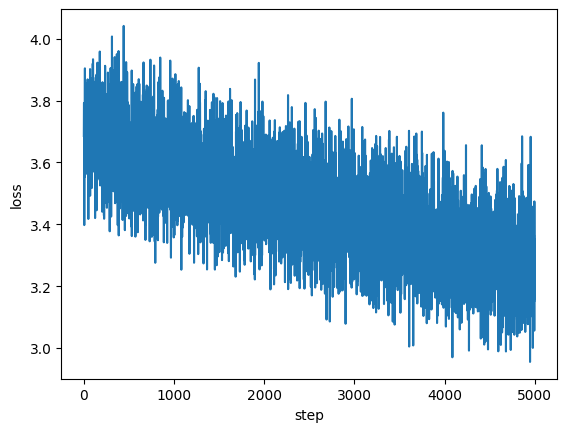

In [141]:
# learning about correct learning rate
losses = []
for i in range(5000):
    xi, yi = get_batch(batch_size)
    logits = model(xi)
    optimizer.zero_grad()
    loss = criterion(logits.view(-1, vocab_size), yi.view(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if i % 100 == 0:
        torch.mps.empty_cache()
    if i % 200 == 0:
        print(f"step {i} loss: {loss.item():.4f}")

plt.plot(losses)
plt.xlabel('step')
plt.ylabel('loss')
plt.show()

Counting words...
Total Unique Words: 42278
Words appearing only once: 9084 (21.5%)


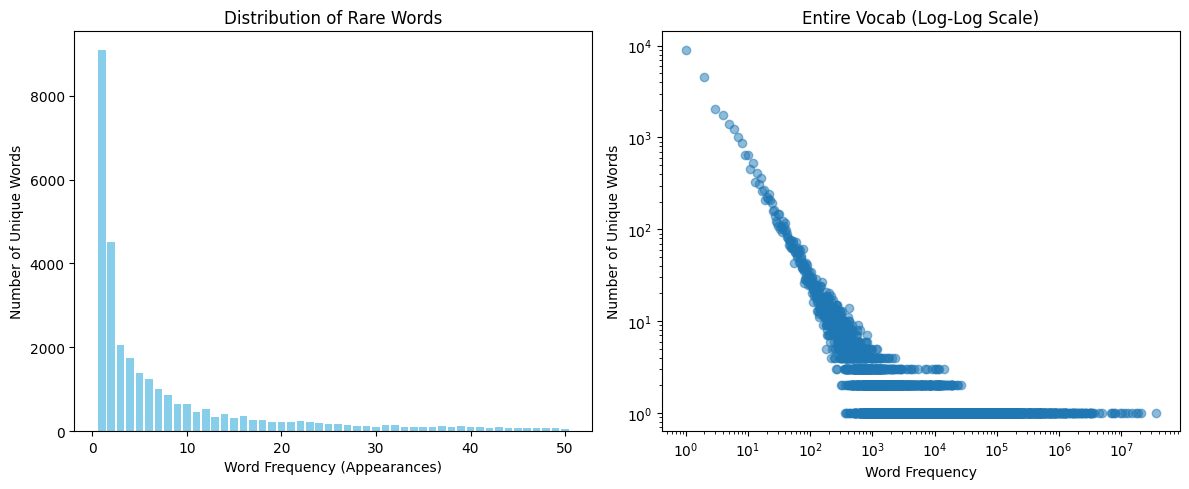

In [23]:
import re
import matplotlib.pyplot as plt
from collections import Counter

input_file = 'TinyStories-train.txt'
pattern = r"<\|.*?\|>|\n|[a-zA-Z]+|[.,!?\"']"
counts = Counter()

print("Counting words...")
with open(input_file, 'r', encoding='utf-8') as f:
    # Limit to 150,000 stories as per your code
    story_count = 0
    for line in f:
        tokens = re.findall(pattern, line.lower())
        counts.update(tokens)
        if '<|endoftext|>' in tokens:
            story_count += 1
            # if story_count >= 150000: break

# Process data for plotting
# How many words appeared exactly 1 time? 2 times? etc.
freq_of_freqs = Counter(counts.values())

# Sort by frequency for the X-axis
sorted_freqs = sorted(freq_of_freqs.keys())
num_words = [freq_of_freqs[f] for f in sorted_freqs]

# --- PRINT STATS ---
total_unique = len(counts)
words_appearing_once = freq_of_freqs[1]
print(f"Total Unique Words: {total_unique}")
print(f"Words appearing only once: {words_appearing_once} ({words_appearing_once/total_unique:.1%})")

# --- PLOTTING ---
plt.figure(figsize=(12, 5))

# Plot 1: The "Long Tail" (Zoomed into words appearing 1-50 times)
plt.subplot(1, 2, 1)
plt.bar(sorted_freqs[:50], num_words[:50], color='skyblue')
plt.title('Distribution of Rare Words')
plt.xlabel('Word Frequency (Appearances)')
plt.ylabel('Number of Unique Words')

# Plot 2: Log-Log plot (Shows the whole distribution)
plt.subplot(1, 2, 2)
plt.loglog(sorted_freqs, num_words, marker='o', linestyle='none', alpha=0.5)
plt.title('Entire Vocab (Log-Log Scale)')
plt.xlabel('Word Frequency')
plt.ylabel('Number of Unique Words')

plt.tight_layout()
plt.show()

In [26]:
words_appearing_once = freq_of_freqs[1]
words_appearing_twicw = freq_of_freqs[2]
words_appearing_thrice = freq_of_freqs[3]
print(words_appearing_once, words_appearing_twicw, words_appearing_thrice, freq_of_freqs[5], freq_of_freqs[6], freq_of_freqs[7], freq_of_freqs[8])

9084 4511 2047 1390 1245 1003 869


In [142]:
model.eval()

def generate_stories(max_words=50):
    tokens = [meta['start_idx']]  # start token
    
    with torch.no_grad():
        for _ in range(max_words):
            # pad to context_len
            context = tokens[-context_len:]
            padded = context + [-1] * (context_len - len(context))
            x = torch.tensor(padded).unsqueeze(0).to(device)  # (1, context_len)
            
            logits = model(x)  # (1, context_len, vocab_size)
            
            # take logits at the last real token position
            last_pos = len(context) - 1
            next_logits = logits[0, last_pos, :]  # (vocab_size,)
            
            probs = F.softmax(next_logits/0.8, dim = -1)
            
            next_token = torch.multinomial(probs, num_samples=1).item()
            
            if next_token == meta['end_idx']:
                break
                
            tokens.append(next_token)
    
    words = [meta['itos'][t] for t in tokens[1:]]  # skip start token
    return ' '.join(words)
for i in range(5):
    print(generate_stories(50)) 
    print("--------------------------------------------------------------------------")
model.train()


 once upon a time , there was a little dog named spot . bobo was always very unhappy , and the best friends . one day jack ' s mom called them . toby said , " let ' s go to the park . " 
 one day
--------------------------------------------------------------------------

 once upon a time , there was a little girl named mary . she was only three years old and loved to play with her friends . one day , her mom put on it in the room . she wanted to help her mom and dad were going
--------------------------------------------------------------------------
once upon a time , there was a little girl named lily . she loved to drink things . one day , lily and lucy went to the park with her friends . 
 lily ' s daddy came into the dishwasher and landed on her friend . she asked
--------------------------------------------------------------------------
once upon a time , there was a naughty little girl named lily . she loved to play outside in the kitchen . one day , she found a big , green sp

AttentionModel(
  (embedding): Embedding(19110, 128, padding_idx=7)
  (position): Embedding(256, 128)
  (Wq): Linear(in_features=128, out_features=128, bias=False)
  (Wk): Linear(in_features=128, out_features=128, bias=False)
  (Wv): Linear(in_features=128, out_features=128, bias=False)
  (Wo): Linear(in_features=128, out_features=128, bias=False)
  (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (first_linear): Linear(in_features=128, out_features=512, bias=True)
  (gelu1): GELU(approximate='none')
  (second_linear): Linear(in_features=512, out_features=512, bias=True)
  (gelu2): GELU(approximate='none')
  (third_linear): Linear(in_features=512, out_features=512, bias=True)
  (gelu3): GELU(approximate='none')
  (fourth_linear): Linear(in_features=512, out_features=128, bias=True)
  (gelu4): GELU(approximate='none')
  (layer_norm_returns): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (logits_linear): Linear(in_features=128, out_features=19110, bias=True

In [144]:
#--------------------------------- ATTENTION WITH LAYERS ----------------------------------------#

In [3]:
# 1. Load Meta
with open('meta.pkl', 'rb') as f:
    meta = pickle.load(f)

# 2. Load the binary files (RAM stays at 0)
# Note: shape is (number_of_stories, 256)
train_X = np.memmap('train_X.bin', dtype=np.uint16, mode='r').reshape(-1, 256)
train_Y = np.memmap('train_Y.bin', dtype=np.uint16, mode='r').reshape(-1, 256)

def get_batch(batch_size):
    # Pick random story indices
    ix = torch.randint(len(train_X), (batch_size,))
    
    # Load just those rows into RAM as torch tensors
    x = torch.from_numpy(train_X[ix].astype(np.int64))
    y = torch.from_numpy(train_Y[ix].astype(np.int64))
    
    return x.to(device), y.to(device)

In [88]:
vocab_size = meta["vocab_size"]
n_embed = 256
batch_size = 12
context_len = 256
n_heads = 4
n_layer = 4
vocab_size

19110

In [89]:
class MLP(nn.Module):
    def __init__(self, n_embed):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(n_embed,4*n_embed),
            nn.GELU(),
            nn.Linear(4*n_embed,n_embed),
        )

    def forward(self, x):
        return self.mlp(x)

In [90]:
class Attention(nn.Module):
    def __init__(self, n_embed, n_heads, pad_idx):
        assert n_embed%n_heads == 0, "n_embed needs to be divisable by n_head" 
        super().__init__()
        self.pad_idx = pad_idx
        self.n_heads = n_heads
        self.head_dim = n_embed//n_heads
        self.Wq = nn.Linear(n_embed,n_embed,bias=False)
        self.Wk = nn.Linear(n_embed,n_embed,bias=False)
        self.Wv = nn.Linear(n_embed,n_embed,bias=False)
        self.Wo = nn.Linear(n_embed,n_embed,bias=False)

    def forward(self, x, causal_mask):
        pad_mask = (x == self.pad_idx).unsqueeze(1).unsqueeze(2).to(x.device)
        B, seq_len = x.shape[0],x.shape[1]
        
        q = self.Wq(x)
        k = self.Wk(x)
        v = self.Wv(x)

        # Reshape for Multi-Head: (B, ctx_len, n_heads, head_dim) 
        # Then transpose to: (B, n_heads, ctx_len, head_dim)
        q = q.view(B, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        
        attn = (q @ k.transpose(-1,-2)) * (self.head_dim ** -0.5)  # (batch, n_heads, context_len, context_len)
        # attn = attn @ self.Wa
        
        mask = causal_mask[:seq_len, :seq_len]
        attn = attn.masked_fill(mask, float('-inf'))
        
        # pad_mask = pad_mask.unsqueeze(1).expand(-1, seq_len, seq_len).to(x.device)
        # attn = attn.masked_fill(pad_mask, float('-inf'))
        
        attn = F.softmax(attn, dim=-1)
        attn = attn @ v
        attn = attn.transpose(1, 2).contiguous().view(B, seq_len, -1) 
        x = x + self.Wo(attn)
        return x

In [91]:
class TransformerBlock(nn.Module):
    def __init__(self, n_embed, n_heads, pad_idx):
        super().__init__()
        self.attention = Attention(n_embed, n_heads, pad_idx)
        self.mlp = MLP(n_embed)
        self.layer_norm1 = nn.LayerNorm(n_embed)
        self.layer_norm2 = nn.LayerNorm(n_embed)
        
    def forward(self, x, causal_mask):
        x = x + self.attention(self.layer_norm1(x), causal_mask=causal_mask)
        x = x + self.mlp(self.layer_norm2(x))
        return x

In [105]:
class GPT(nn.Module):
    def __init__(self, n_embed, n_heads, vocab_size, context_len, n_layer, pad_idx):
        super().__init__()
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(vocab_size, n_embed),
            wpe = nn.Embedding(context_len, n_embed),
            h = nn.ModuleList([TransformerBlock(n_embed, n_heads, pad_idx) for _ in range(n_layer)]),
        ))
        self.layer_norm = nn.LayerNorm(n_embed)
        self.linear_out = nn.Linear(n_embed, vocab_size, bias=False)

        #linear_out stores as a transpose which is vocab_size x n_embed. but embedding is not stored as transpose vocab_size x n_embed.
        # these can be the same matrices because we are having the same embedding matrix
        self.linear_out.weight = self.transformer.wte.weight
        
        mask = torch.triu(torch.ones(context_len, context_len), diagonal=1).bool()
        self.register_buffer("causal_mask", mask)
        
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.zeros_(module.bias)
            torch.nn.init.ones_(module.weight)
        
    def forward(self, x):
        batch, seq_len = x.shape[0],x.shape[1]
        
        # Create position indices
        pos = torch.arange(0, seq_len, dtype=torch.long, device=device)
        
        tok_emb = self.transformer.wte(x)
        pos_emb = self.transformer.wpe(pos)
        x = tok_emb + pos_emb
        
        # Transformer Blocks
        for block in self.transformer.h:
            x = block(x, causal_mask=self.causal_mask)
            
        x = self.layer_norm(x)
        logits = self.linear_out(x)
        return logits

In [106]:
model = GPT(n_embed,n_heads,vocab_size,context_len,n_layer, meta["pad_idx"]).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=meta["pad_idx"],reduction='mean')

In [107]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Params: {total_params:,}")

Total Trainable Params: 8,113,152


In [124]:
new_lr = 5e-5
for param_group in optimizer.param_groups:
    param_group['lr'] = new_lr

step 0 loss: 2.2265
step 100 loss: 2.1483
step 200 loss: 2.2321
step 300 loss: 2.3494
step 400 loss: 2.4563
step 500 loss: 2.3408
step 600 loss: 2.2960
step 700 loss: 2.1004
step 800 loss: 2.3075
step 900 loss: 2.3707


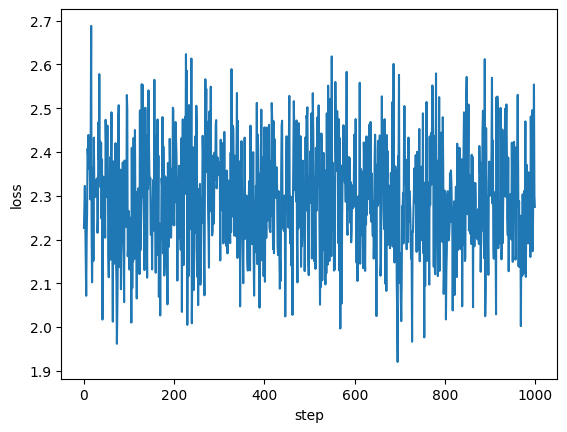

In [126]:
# learning about correct learning rate
losses = []
for i in range(1000):
    xi, yi = get_batch(batch_size)
    logits = model(xi)
    optimizer.zero_grad()
    loss = criterion(logits.view(-1, vocab_size), yi.view(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if i % 100 == 0:
        torch.mps.empty_cache()
    if i % 100 == 0:
        print(f"step {i} loss: {loss.item():.4f}")

plt.plot(losses)
plt.xlabel('step')
plt.ylabel('loss')
plt.show()

In [128]:
model.eval()

def generate_stories(max_words=50):
    tokens = [meta['start_idx']]  # start token
    
    with torch.no_grad():
        for _ in range(max_words):
            # pad to context_len
            context = tokens[-context_len:]
            padded = context + [-1] * (context_len - len(context))
            x = torch.tensor(padded).unsqueeze(0).to(device)  # (1, context_len)
            
            logits = model(x)  # (1, context_len, vocab_size)
            
            # take logits at the last real token position
            last_pos = len(context) - 1
            next_logits = logits[0, last_pos, :]  # (vocab_size,)
            
            probs = F.softmax(next_logits, dim = -1)
            
            next_token = torch.multinomial(probs, num_samples=1).item()
            
            if next_token == meta['end_idx']:
                break
                
            tokens.append(next_token)
    
    words = [meta['itos'][t] for t in tokens[1:]]  # skip start token
    return ' '.join(words)
for i in range(5):
    print(generate_stories(50)) 
    print("--------------------------------------------------------------------------")
model.train()


 once upon a time , there were two best friends named lila and buddy . they had a massage one day . 
 one day , papa , maria and bella ' s mum found a video which she was playing with them . tina quickly put on a
--------------------------------------------------------------------------
once upon a time , there was a happy dog named spot . spot loved to bark and play with spot very well . one day , spot went to the creek far away . he found a big rock and wanted to lift it . 
 spot asked his
--------------------------------------------------------------------------
once upon a time , there was a little girl named lily . lily loved watching cartoons on the same path and everyday night loved to watch cartoons in time . one day , she put on her backpack and went to the playground to play the park one day
--------------------------------------------------------------------------
once upon a time , there was a wild egg named ducky . when betsy was walking , she spotted a stuck in the groun

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(19110, 256)
    (wpe): Embedding(256, 256)
    (h): ModuleList(
      (0-3): 4 x TransformerBlock(
        (attention): Attention(
          (Wq): Linear(in_features=256, out_features=256, bias=False)
          (Wk): Linear(in_features=256, out_features=256, bias=False)
          (Wv): Linear(in_features=256, out_features=256, bias=False)
          (Wo): Linear(in_features=256, out_features=256, bias=False)
        )
        (mlp): MLP(
          (mlp): Sequential(
            (0): Linear(in_features=256, out_features=1024, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=1024, out_features=256, bias=True)
          )
        )
        (layer_norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (layer_norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (linear_out): Linear(in_f

In [115]:
# 2. Load the binary files (RAM stays at 0)
# Note: shape is (number_of_stories, 256)
val_X = np.memmap('val_X.bin', dtype=np.uint16, mode='r').reshape(-1, 256)
val_Y = np.memmap('val_Y.bin', dtype=np.uint16, mode='r').reshape(-1, 256)

def get_batch_valid(batch_size):
    # Pick random story indices
    ix = torch.randint(len(val_X), (batch_size,))
    
    # Load just those rows into RAM as torch tensors
    x = torch.from_numpy(val_X[ix].astype(np.int64))
    y = torch.from_numpy(val_Y[ix].astype(np.int64))
    
    return x.to(device), y.to(device)

step 0 loss: 2.4176
step 100 loss: 2.5161
step 200 loss: 2.3297
step 300 loss: 2.2397
step 400 loss: 2.4096
step 500 loss: 2.4270
step 600 loss: 2.2650
step 700 loss: 2.3519
step 800 loss: 2.5367
step 900 loss: 2.2648


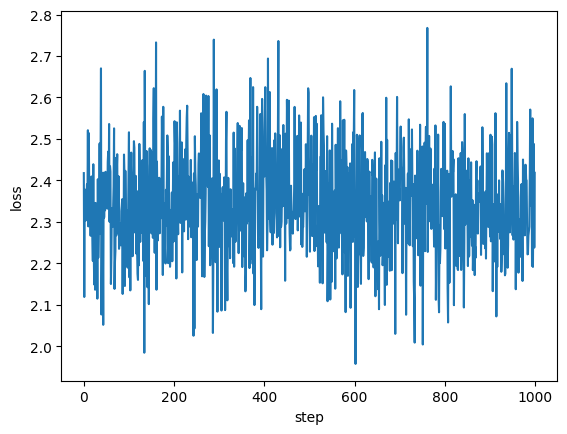

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(19110, 256)
    (wpe): Embedding(256, 256)
    (h): ModuleList(
      (0-3): 4 x TransformerBlock(
        (attention): Attention(
          (Wq): Linear(in_features=256, out_features=256, bias=False)
          (Wk): Linear(in_features=256, out_features=256, bias=False)
          (Wv): Linear(in_features=256, out_features=256, bias=False)
          (Wo): Linear(in_features=256, out_features=256, bias=False)
        )
        (mlp): MLP(
          (mlp): Sequential(
            (0): Linear(in_features=256, out_features=1024, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=1024, out_features=256, bias=True)
          )
        )
        (layer_norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (layer_norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (linear_out): Linear(in_f

In [123]:
model.eval()

losses = []
for i in range(1000):
    xi, yi = get_batch_valid(batch_size)
    logits = model(xi)
    optimizer.zero_grad()
    loss = criterion(logits.view(-1, vocab_size), yi.view(-1))
    losses.append(loss.item())
    if i % 100 == 0:
        torch.mps.empty_cache()
    if i % 100 == 0:
        print(f"step {i} loss: {loss.item():.4f}")
plt.plot(losses)
plt.xlabel('step')
plt.ylabel('loss')
plt.show()
model.train()